In [62]:
import torch # install GPU-compatible
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, get_linear_schedule_with_warmup, AutoConfig
from datasets import Dataset
import evaluate
from tqdm import tqdm
from torch.nn import functional as F
import numpy as np
import pandas as pd
from torch.optim import AdamW
#from sysml_utils import SysMLASTManager
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments
from transformers import default_data_collator

model_name = "Salesforce/codet5-small"
cache_dir = "./models" 

import os
os.makedirs("models/trained", exist_ok=True)

In [ ]:
# load the data
# set ids

In [95]:
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, cache_dir=cache_dir)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def count_tokens(text: str) -> int:
    tokens = tokenizer.encode(text, add_special_tokens=False)
    return len(tokens)

In [64]:
import matplotlib.pyplot as plt

def plot_token_lengths(dataset, column_name):

    # Handle both Hugging Face Dataset and pandas DataFrame
    if hasattr(dataset, "to_pandas"):
        texts = dataset[column_name]  # works for Hugging Face Datasets
    else:
        texts = dataset[column_name]  # works for pandas DataFrame

    # Convert all entries to string (safe)
    texts = [str(t) for t in texts]

    # Tokenize and count
    token_counts = [len(tokenizer.encode(t, add_special_tokens=False)) for t in texts]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(token_counts)), token_counts)
    plt.xlabel("Example index")
    plt.ylabel("Token count")
    plt.title(f"Token counts per example")
    plt.grid(True)
    plt.show()

    return token_counts


In [ ]:
train_syntax_df = pd.read_json("split_data/train_syntax.jsonl", lines=True)
train_domain_df = pd.read_json("split_data/train_domain.jsonl", lines=True) 

val_syntax_df = pd.read_json("split_data/val_syntax_valid.jsonl", lines=True)
val_domain_df = pd.read_json("split_data/val_domain.jsonl", lines=True) 

#merged_df = pd.concat([train_syntax_df, train_domain_df, val_syntax_df, val_domain_df], ignore_index=True)


syntax_df = pd.concat([train_syntax_df, val_syntax_df], ignore_index=True)
syntax_df['mutation_category'] = 'syntax'
syntax_df['id'] = 's_' + (syntax_df.index + 1).astype(str).str.zfill(4)
syntax_dataset = Dataset.from_pandas(syntax_df)

domain_df = pd.concat([train_domain_df, val_domain_df], ignore_index=True)
domain_df['mutation_category'] = 'domain'
domain_df['id'] = 'd_' + (domain_df.index + 1).astype(str).str.zfill(4)
domain_dataset = Dataset.from_pandas(domain_df)

merged_df = pd.concat([syntax_df, domain_df], ignore_index=True)
merged_df = merged_df[['id', 'source_id', 'mutation_category', 'mutation_type', 'bad_code', 'error_message', 'good_code']]

# 5497 are from syntax, 1402 from domain

In [230]:
merged_df.to_json('complete_sysmlv2_dataset.jsonl', orient='records', lines=True)

In [218]:
from vehicle_kg import TYPE_TO_DOMAIN, VALID_CONNECTIONS
import re

def get_kg_context(code):
    """Scans code and retrieves relevant domain rules."""
    context_lines = []
    found_domains = set()
    for type_name, domain in TYPE_TO_DOMAIN.items():
        if re.search(r'\b' + re.escape(type_name) + r'\b', code):
            context_lines.append(f"- '{type_name}' belongs to Domain: {domain}")
            found_domains.add(domain)
    
    if found_domains:
        context_lines.append("\nValid Connections Rules:")
        for domain in found_domains:
            allowed = VALID_CONNECTIONS.get(domain, [])
            context_lines.append(f"- {domain} can ONLY connect to: {allowed}")
    return context_lines

In [224]:
dataset = Dataset.from_pandas(merged_df)

types, msgs, kg_rules = [], [], []

for example in dataset:
    cat = example['mutation_category']
    if cat == "domain":
        type = example["mutation_type"]
        msg = example["error_message"]
        num_rules = len(get_kg_context(example["bad_code"]))
        #if num_rules == 0:
            #print(msg)

        kg_rules.append(num_rules)

        if type not in types:
            types.append(type)
            msgs.append(msg)
            print(example["mutation_type"])
            print(example["error_message"])
            print("-----")


mismatch_quantity_kind_type
ERROR:Type mismatch: Attribute 'power' declared as 'ISQ::force' but should be 'ISQ::power' based on semantic meaning (line : 30)
-----
mutate_valid_connection_to_domain_error
ERROR:Domain violation: Port 'battery.batteryBehavior.output' (electrical_power) cannot connect to 'tire.tireBehavior.input' (mechanical_torque) (line : 182)
-----
swap_unit_incompatibly
ERROR:Quantity mismatch: Attribute 'mass' has type 'ISQ::mass' (mass) but assigned value with incompatible unit 'W' (line : 9)
-----
break_compound_unit_expression
ERROR:Unit expression corruption: Changed multiplication to division in compound unit '[N * m]' to '[N/m]' (line : 15)
-----
create_domain_mismatch_connection
ERROR:Domain violation: Port 'rightHalfAxle.shankCompositePort' (mechanical_fastening) cannot connect to 'vehicleLogical.vehicleToRoadPort' (mechanical_torque) (line : 1583)
-----


In [ ]:
def parse_error_message(error_string: str) -> tuple:
    # Strip "ERROR:" prefix
    error_string = error_string.replace("ERROR:", "").strip()
    
    # Remove the "(line ...)" part
    if " (line : " in error_string:
        error_string = error_string.split(" (line : ")[0].strip()
    
    # Split by first colon to get error type and message
    parts = error_string.split(":", 1)
    error_type = parts[0].strip()
    message = parts[1].strip() if len(parts) > 1 else ""
    
    return (error_type, message)

In [ ]:
def create_thought(error_message: str, mutation_category: str) -> str:

    solution_map = {
    "Type mismatch": "To solve this, the attribute declaration should be renamed correctly based on semantic meaning",
    "Domain violation": "To solve this, we need to reroute this connection to a compatible port as per the rules",
    "Quantity mismatch": "To solve this, we need to assign correct units to this attribute",
    "Unit expression corruption": "To solve this, the unit must be corrected to valid form"
    }

    if mutation_category == "domain":
        error_type, error_desc = parse_error_message(error_message)
        return f"Let's think step-by-step.\nChecking the rules, reading the code.\n{error_desc}.\n{solution_map.get(error_type, '')}."
    elif mutation_category == "syntax":
        return f"Let's think step-by-step.\nThe compiler reports syntax errors. \nTo solve this, we need to fix the syntax issues in the code at the reported lines."

In [ ]:
def create_fix(patches: list[dict]) -> str:
    fixes = []
    for i, patch in enumerate(patches):
        context = patch.get("context", "")
        before = patch.get("before", "")
        after = patch.get("after", "")

        # Add separator for subsequent patches
        parts = ["\n\nAND " if i > 0 else ""]
        
        # Add context if present
        if context:
            parts.append(f"AFTER THIS CODE:\n{context}\n\n")
        
        # Determine operation type
        if before and after:
            parts.append(f"REPLACE:\n{before}\n\nWITH:\n{after}")
        elif before:
            parts.append(f"DELETE:\n{before}")
        elif after:
            parts.append(f"INSERT:\n{after}")
        
        fixes.append("".join(parts))
    
    return "".join(fixes)

In [223]:
print(kg_rules)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 3, 5, 5, 6, 6, 5, 6, 6, 6, 6, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 5, 5, 6, 5, 6, 5, 5, 5, 6, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 5, 5, 6, 5, 6, 6, 6, 6, 6, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 5, 6, 5, 5, 5, 6, 6, 6, 5, 5, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 6, 5, 6, 6, 6, 5, 6, 5, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 6, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 6, 6, 5, 5, 6, 5, 6, 6, 6, 6, 6, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 5, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 5, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 5, 5, 6, 5, 5, 5, 6, 6, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 5, 5, 6, 6, 5, 6, 6, 6, 5, 6, 5, 6, 6, 6, 6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 6, 

In [207]:
def process_errors(text: str) -> str:
    return text.replace("ERROR:", "\nERROR:").lstrip()

In [208]:
from patching import generate_contextual_patches

def patch_gen_all(example): 
    return generate_contextual_patches(example["bad_code"], example["good_code"])

def process_error_all(example):
    return process_errors(example["error_message"])

merged_df['error_message'] = merged_df.apply(process_error_all, axis=1)
merged_df['fix_patches'] = merged_df.apply(patch_gen_all, axis=1)

In [182]:

domain_records = pd.read_json("synthetic_dataset_domain_aware_full12.jsonl", lines=True)
syntax_records = pd.read_json("synthetic_dataset_main_expanded_new_final2.jsonl", lines=True)


merged_df = pd.concat([domain_records, syntax_records], ignore_index=True)
dataset = Dataset.from_pandas(merged_df)

In [174]:
len(dataset)

7072

In [168]:
analysis["heuristic_counts"]

{('syntax', 'break_imports'): 426,
 ('syntax', 'remove_random_semicolon'): 1284,
 ('syntax', 'delete_random_closing_bracket'): 1293,
 ('syntax', 'swap_keywords'): 1170,
 ('syntax', 'subsets_redefines_swap'): 15,
 ('syntax', 'break_connect_endpoint_name'): 37,
 ('syntax', 'unit_mismatch_edit'): 43,
 ('syntax', 'drop_units_on_quantity_value'): 8,
 ('syntax', 'rename_definition_break_usages'): 1158,
 ('syntax', 'duplicate_feature_in_scope'): 30,
 ('syntax', 'corrupt_qualified_reference'): 166,
 ('syntax', 'multiplicity_inversion'): 4,
 ('syntax', 'flip_port_complement'): 12,
 ('syntax', 'delete_flow_statement'): 4,
 ('syntax', 'flip_import_visibility'): 8,
 ('syntax', 'remove_public_import_line'): 12,
 ('domain', 'mismatch_quantity_kind_type'): 86,
 ('domain', 'mutate_valid_connection_to_domain_error'): 1077,
 ('domain', 'swap_unit_incompatibly'): 8,
 ('domain', 'create_domain_mismatch_connection'): 228,
 ('domain', 'break_compound_unit_expression'): 3}

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

df = dataset.to_pandas()
print(df["mutation_type"].value_counts())


mutation_type
mutate_valid_connection_to_domain_error    1077
create_domain_mismatch_connection           228
mismatch_quantity_kind_type                  86
swap_unit_incompatibly                        8
break_compound_unit_expression                3
Name: count, dtype: int64


In [177]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_columns')


Normal counts: 5465 out of 6899


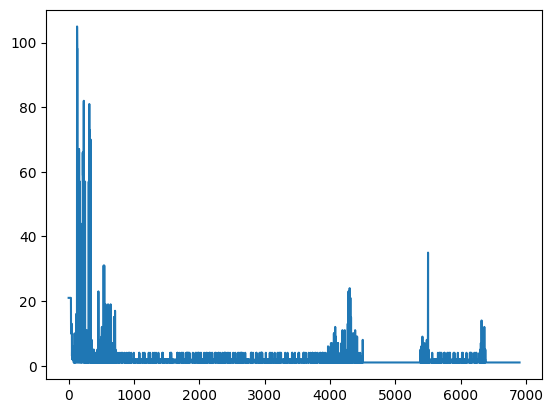

In [200]:
def count_errors(text: str) -> int:
    return text.count("ERROR:")

counts = []
normal_counts = []

for idx, example in enumerate(full_dataset):
    error_count = count_errors(example["error_message"])
    counts.append(error_count)
    if error_count == 1:
        normal_counts.append(error_count)

print(f"Normal counts: {len(normal_counts)} out of {len(counts)}")

plt.plot(counts)
plt.show()

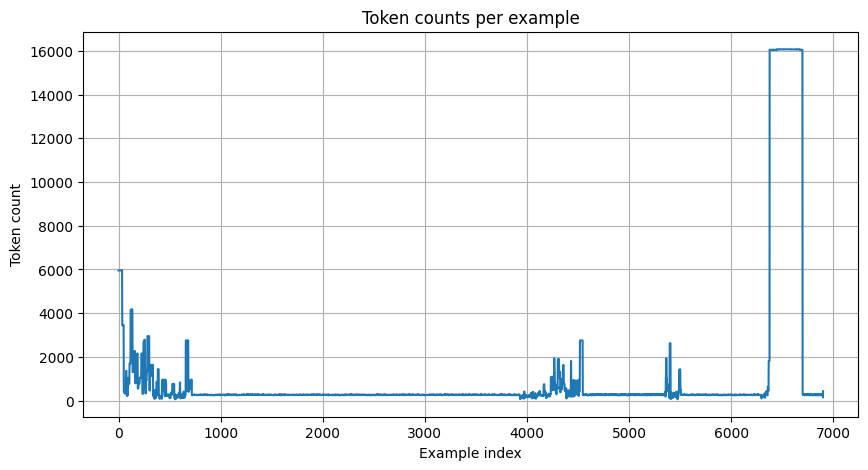

In [119]:
token_counts = plot_token_lengths(dataset, "bad_code")

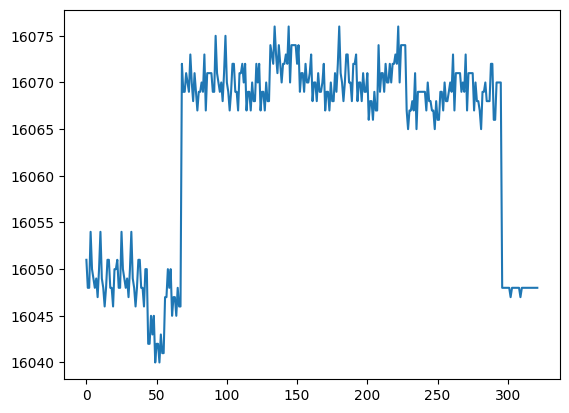

In [140]:
def count_tokens(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))


exps = []
for example in dataset:
    src_id = example["source_id"]
    if src_id == "src_0150":
        toks = count_tokens(example["bad_code"])
        exps.append(toks)

plt.plot(exps)
plt.show()

In [111]:
import re
from typing import List

def extract_last_error_location(error: str) -> List[int]:
    """Extract last error line number based on "line : number" format"""
    
    pattern = r'line : (\d+)'
    matches = re.findall(pattern, error)
    nums = [int(num) for num in matches]

    if not nums:
        raise ValueError("No line numbers found in the error string.")

    return max(nums)


def truncate_beyond_last_error(code: str, error: str) -> str:
    """Truncate code, keeping everything up to the line after the error."""
    
    err_line = extract_last_error_location(error)
    lines = code.splitlines()
    
    return "\n".join(lines[:err_line+1])

In [81]:
example = dataset[1494]
error = example["error_message"]
print(error)

ERROR:Quantity mismatch: Attribute 'mass' has type 'ISQ::mass' (mass) but assigned value with incompatible unit 'V' (line : 12)


In [90]:
example = dataset[1494]
error = example["error_message"]
code = example["bad_code"]
truncated_code = truncate_beyond_last_error(code, error)
print(truncated_code)

package '11a-View-Viewpoint' {
	
	package SystemModel {
		private import SI::*;
		
		part def Vehicle;
		part def AxleAssembly;
		part def Axle;
		part def Wheel;
		
		part vehicle : Vehicle {
			attribute mass :> ISQ::mass = 2500[V];
			part frontAxleAssembly : AxleAssembly[1] {


In [112]:
def count_lines(s):
    print(len(s.splitlines()))

def count_tokens(text: str) -> int:
    tokens = tokenizer.encode(text, add_special_tokens=False)
    print(len(tokens))

def get_line(text, n):
    print(text.splitlines()[n - 1])

In [114]:
toks, tr_toks = [], []

for example in dataset:
    error = example["error_message"]
    bad_code = example["bad_code"]
    truncated_bad_code = truncate_beyond_last_error(bad_code, error)

    toks.append(count_tokens(bad_code)) 
    tr_toks.append(count_tokens(truncated_bad_code))

diff = [o - t for o, t in zip(toks, tr_toks)]
import random

random.shuffle(diff)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
#plt.plot(toks, label="Original")
#plt.plot(tr_toks, label="Truncated")
plt.plot(diff, label="Difference")
plt.xlabel("Example index")
plt.ylabel("Token count")
plt.title("Token counts: Original vs Truncated")
plt.legend()


328
31
328
33
329
329
329
329
330
200
937
24
937
937
936
936
938
798
943
911
939
582
1318
44
1318
992
1318
1141
1318
1318
1319
1307
1319
34
2944
27
2944
39
2944
42
2944
65
2944
80
2944
91
2944
107
2944
109
2944
139
2944
140
2945
2360
2943
2943
2945
652
2945
693
2945
726
2944
692
2946
895
2950
252
2945
1698
457
37
457
49
457
50
457
254
456
456
458
453
463
458
469
464
1626
94
1626
106
1626
116
1626
1626
1625
1625
1627
1607
1627
1607
1627
1607
1626
1606
1628
1608
1632
1612
1635
1615
1628
1608
1133
28
1133
540
1134
152
1132
1132
1136
365
1135
1131
1625
67
1625
79
1625
88
1625
90
1625
268
1624
1624
1626
1397
1626
1397
1631
1402
1626
1397
412
339
412
412
413
365
192
32
192
191
411
336
411
411
413
365
302
260
301
301
303
255
80
15
80
15
80
79
81
77
82
78
102
102
101
100
473
17
473
393
473
472
479
280
173
17
173
141
172
172
175
171
102
101
449
449
449
449
450
245
450
130
451
175
455
179
121
35
120
120
124
103
123
118
854
25
854
33
854
93
854
719
853
853
860
273
855
46
241
32
242
173
240
240
24

TypeError: unsupported operand type(s) for -: 'NoneType' and 'NoneType'

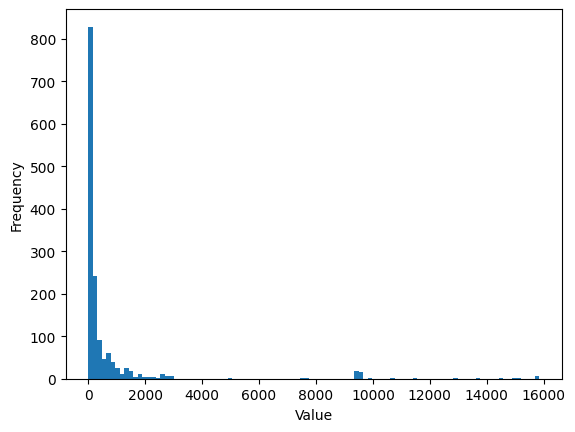

In [108]:
import matplotlib.pyplot as plt

plt.hist(diff, bins=100)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [ ]:
error = example["error_message"]
formatted_error = error.replace("ERROR:", "\nERROR:")
code = example["bad_code"]
count_tokens(code)
count_tokens(error)
get_line(code, 81)

In [ ]:
print(formatted_error)
print(code)

In [ ]:
text = example["bad_code"]
print(count_tokens(text))  
print(text)

In [ ]:
def count_lines(s):
    print(len(s.splitlines()))

count_lines(example["bad_code"])

In [ ]:
bad_code = '''part system {
            part eng : Engine;      // mechanical
            part bulb : Light;      // electrical
            part trans : Gearbox;   // mechanical
            
        }'''

good_code = '''part system {
            part eng : Engine;      // mechanical
            part bulb : Light;      // electrical
            part trans : Gearbox;   // mechanical
            
            connect eng.p to trans.p;
        }'''
from typing import List, Dict
def count_occurrences(haystack: List[str], needle: List[str]) -> int:
    if not needle:
        return 0
    count = 0
    n = len(needle)
    for i in range(len(haystack) - n + 1):
        if haystack[i:i+n] == needle:
            count += 1
    return count

In [ ]:
from typing import List, Dict, Optional
import difflib


def compare_code_lines(bad_lines: list[str], good_lines: list[str], merge_threshold: int) -> Optional[list[tuple]]:
    """Compare two lists of code lines and return merged diff hunks."""
    matcher = difflib.SequenceMatcher(a=bad_lines, b=good_lines)
    raw_hunks = [
        (i1, i2, j1, j2)
        for tag, i1, i2, j1, j2 in matcher.get_opcodes()
        if tag != "equal"
    ]

    if not raw_hunks:
        return None

    merged = []
    current = list(raw_hunks[0])

    for i1, i2, j1, j2 in raw_hunks[1:]:
        if i1 - current[1] <= merge_threshold:
            current[1] = i2  # extend bad-region end
            current[3] = j2  # extend good-region end
        else:
            merged.append(tuple(current))
            current = [i1, i2, j1, j2]

    merged.append(tuple(current))
    return merged


def is_all_empty(strings: list[str]) -> bool:
    """Check if all strings are empty or whitespace-only."""
    return all(not s.strip() for s in strings)


def occurs_exactly_once(haystack: list[str], needle: list[str]) -> bool:
    """Check if needle appears exactly once in haystack."""
    if not needle:
        return False
    
    needle_len = len(needle)
    haystack_len = len(haystack)
    count = 0
    
    for i in range(haystack_len - needle_len + 1):
        if haystack[i : i + needle_len] == needle:
            count += 1
            if count > 1:  # Early exit optimization
                return False
    
    return count == 1


def generate_contextual_patches(
        bad_code: str,
        good_code: str,
        merge_threshold: int = 3, 
        max_context: int = 50
        ) -> List[Dict[str, str]]:

    """Generate contextual patches to transform bad_code into good_code."""
    bad_lines = bad_code.splitlines()
    good_lines = good_code.splitlines()

    merged = compare_code_lines(bad_lines, good_lines, merge_threshold)

    if not merged:
        return []

    patches = []

    for i1, i2, j1, j2 in merged:
        before_block = bad_lines[i1:i2]
        after_block = good_lines[j1:j2]

        # If before_block is non-empty and unique, no context needed
        if not is_all_empty(before_block) and occurs_exactly_once(bad_lines, before_block):
            
            patches.append({
                "context": "",
                "before": "\n".join(before_block),
                "after": "\n".join(after_block),
            })
        
        else:
            # Need to find unique context
            context_size = 0
            context_before = []

            while context_size < max_context:
                # Expand context backwards until we hit a non-empty line
                while context_size < i1:
                    context_size += 1
                    context_before = bad_lines[i1 - context_size : i1]
                    if not is_all_empty(context_before):
                        break
                
                # Check if context + before_block is unique
                candidate = context_before + before_block
                if occurs_exactly_once(bad_lines, candidate) or context_size >= i1:
                    break

                # Need more context - increment and continue
                if context_size < i1:
                    context_size += 1
                    context_before = bad_lines[i1 - context_size : i1]
                else:
                    break

            patches.append({
                "context": "\n".join(context_before),
                "before": "\n".join(before_block),
                "after": "\n".join(after_block),
            })

    return patches

In [ ]:
example = dataset[7]
bad_code = example["bad_code"]
good_code = example["good_code"]
error = example["error_message"]
patches = generate_contextual_patches(bad_code, good_code)
print(patches)


In [ ]:
ans = generate_contextual_patches(bad_code, good_code)
print(ans)

In [ ]:
def apply_patches(bad_code: str, patches: List[Dict[str, str]]) -> str:
    """
    Apply context-aware BEFORE/AFTER patches to code.
    
    Patches have keys:
        "context": str  (may be empty)
        "before": str
        "after": str
    
    Returns updated code after all patches are applied.
    
    Raises:
        RuntimeError: If a patch cannot be located in the code.
    """
    lines = bad_code.splitlines()

    for i, patch in enumerate(patches):
        context = patch["context"].splitlines() if patch["context"] else []
        before = patch["before"].splitlines()
        after = patch["after"].splitlines()

        target_block = context + before
        replacement_block = context + after

        # Find the target block
        idx = find_exact_sublist(lines, target_block)

        if idx == -1:
            raise RuntimeError(
                f"Could not locate patch {i + 1}/{len(patches)} in code. "
                f"Target block: {target_block[:2]}..."  # Show first 2 lines for debugging
            )

        # Apply replacement
        end_idx = idx + len(target_block)
        lines = lines[:idx] + replacement_block + lines[end_idx:]

    return "\n".join(lines)


def find_exact_sublist(haystack: List[str], needle: List[str]) -> int:
    """
    Find the first exact consecutive match of needle in haystack.
    
    Args:
        haystack: List to search in
        needle: List to search for
    
    Returns:
        Starting index of the match, or -1 if not found.
    """
    if not needle:
        return -1

    needle_len = len(needle)
    haystack_len = len(haystack)

    # Early exit if needle is longer than haystack
    if needle_len > haystack_len:
        return -1

    for i in range(haystack_len - needle_len + 1):
        if haystack[i : i + needle_len] == needle:
            return i

    return -1

In [ ]:
def codes_match_strict(corrected: str, good: str) -> bool:
    return corrected == good

def codes_match_normalized(corrected: str, expected: str) -> bool:
    def normalize(code: str):
        # Remove trailing spaces, normalize newlines, collapse indent variations
        return "\n".join(line.rstrip() for line in code.splitlines()).strip()

    return normalize(corrected) == normalize(expected)


In [ ]:
passed = []
failed = []
err_failed = []

def codes_match_strict(corrected: str, good: str) -> bool:
    return corrected == good

for idx, example in enumerate(dataset):
    try: 
        bad_code = example["bad_code"]
        good_code = example["good_code"]
    
        if codes_match_strict(bad_code, good_code):
            passed.append(idx)
        else:
            failed.append(idx)
    except Exception as e:
        err_failed.append((idx))

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")
print(passed)

# Answer
# Passed: 3, Failed: 1496, Errors: 0
# [1479, 1482, 1484]

Passed: 3, Failed: 1496, Errors: 0
[1479, 1482, 1484]


In [75]:
print(dataset[1479])

{'source_id': 'src_0249', 'mutation_type': 'swap_unit_incompatibly', 'bad_code': 'package \'1a-Parts Tree\' {\n\tprivate import SI::kg;\n\t\n\tpackage Definitions {\t\n\t\tpart def Vehicle {\n\t\t\tattribute mass :> ISQ::mass {\n\t\t\tdoc\n\t\t\t/*\n\t\t\t * The \'mass\' attribute property is declared here to be a \n\t\t\t * specialization (subset) of the general \'mass\' quantity \n\t\t\t * from the \'ISQ\' (International System of Quantities) \n\t\t\t * library model.\n\t\t\t */\n\t\t\t}\n\t\t}\t\t\n\t\tpart def AxleAssembly;\t\t\n\t\tpart def Axle { \n\t\t\tattribute mass :> ISQ::mass;\n\t\t}\t\n\t\tpart def FrontAxle :> Axle { \n\t\t\tattribute steeringAngle: ScalarValues::Real;\n\t\t}\t\n\t\tpart def Wheel;\t\n\t}\n\t\n\tpackage Usages {\n\t\tprivate import Definitions::* {\n\t\t\t/*\n\t\t\t * A "private" private import makes the imported names private to the\n\t\t\t * imported package.\n\t\t\t */\n\t\t}\n\t\n\t\tpart vehicle1: Vehicle {\n\t\t\t/*\n\t\t\t * \'vehicle1\' is a packa

In [ ]:
for idx in passed:
    dataset[idx]

In [ ]:
passed = []
failed = []
err_failed = []

for idx, example in enumerate(dataset):
    try: 
        bad_code = example["bad_code"]
        good_code = example["good_code"]
        patches = generate_contextual_patches(bad_code, good_code)
        corrected_code = apply_patches(bad_code, patches)
        if codes_match_normalized(corrected_code, good_code):
            passed.append(idx)
        else:
            failed.append(idx)
    except Exception as e:
        err_failed.append((idx))

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")
print("Failed indices:", failed)

In [ ]:
passed = []
failed = []
err_failed = []

for idx, example in enumerate(dataset):
    try: 
        bad_code = example["bad_code"]
        good_code = example["good_code"]
        patches = generate_contextual_patches(bad_code, good_code)
        
        if patches:
            passed.append(idx)
        else:
            failed.append(idx)
    except Exception as e:
        err_failed.append((idx))

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")
print("Failed indices:", failed)

In [ ]:
import difflib

def print_diff(a: str, b: str, title_a="Corrected", title_b="Expected"):
    diff = difflib.unified_diff(
        a.splitlines(),
        b.splitlines(),
        fromfile=title_a,
        tofile=title_b,
        lineterm=""
    )
    print("\n".join(diff))


passed = []
failed = []
err_failed = []

for idx, example in enumerate(dataset):
    try:
        bad_code = example["bad_code"]
        good_code = example["good_code"]

        patches = generate_contextual_patches(bad_code, good_code)
        corrected_code = apply_patches(bad_code, patches)

        if codes_match_normalized(corrected_code, good_code):
            passed.append(idx)
        else:
            failed.append(idx)

            print("=" * 60)
            print(f"FAILED EXAMPLE {idx}")

            # Show the patches generated
            print("\nPATCHES:")
            for p in patches:
                print("\n--- PATCH ---")
                print("CONTEXT:\n", p["context"])
                print("BEFORE:\n", p["before"])
                print("AFTER:\n", p["after"])

            # Show diff between corrected and expected code
            print("\nDIFF (Corrected vs Expected):")
            print_diff(corrected_code, good_code)

            # Optional: show diff between bad code and good code
            print("\nDIFF (Bad vs Expected):")
            print_diff(bad_code, good_code)

            print("=" * 60)

    except Exception as e:
        err_failed.append(idx)
        print("=" * 60)
        print(f"ERROR in EXAMPLE {idx}: {e}")
        print("=" * 60)

print(f"Passed: {len(passed)}, Failed: {len(failed)}, Errors: {len(err_failed)}")


In [ ]:
def preprocess_data(batch, keep_original=True):
    input_texts = [
        f"Fix the following SysML code.\n### Faulty Code:\n{wc}\n### Error:\n{err}"
        for wc, err in zip(batch["bad_code"], batch["error_message"])
    ]
    target_texts = [
        f"Here is the correct code:\n{code}"
        for code in batch["good_code"]
    ]

    if keep_original:
        batch["input_text"] = input_texts
        batch["target_text"] = target_texts
        return batch
    else:
        return {"input_text": input_texts, "target_text": target_texts}


def group_split(dataset, test_size=0.1, val_size=0.1, seed=42):
    base_ids = list(set(dataset["source_id"]))
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(base_ids)

    n = len(shuffled)
    n_test = int(test_size * n)
    n_val = int(val_size * n)

    test_groups = set(shuffled[:n_test])
    val_groups  = set(shuffled[n_test:n_test+n_val])

    def label_row(example):
        if example["source_id"] in test_groups:
            return {"split": "test"}
        elif example["source_id"] in val_groups:
            return {"split": "val"}
        else:
            return {"split": "train"}

    dataset = dataset.map(label_row)

    train_ds = dataset.filter(lambda x: x["split"] == "train").remove_columns("split")
    val_ds   = dataset.filter(lambda x: x["split"] == "val").remove_columns("split")
    test_ds  = dataset.filter(lambda x: x["split"] == "test").remove_columns("split")

    return train_ds, val_ds, test_ds

dataset = dataset.map(preprocess_data, batched=True)
train_ds, val_ds, test_ds = group_split(dataset)
print(f"Datatset Sizes: \nTraining: {len(train_ds)}, Validation: {len(val_ds)}, Test: {len(test_ds)}")

In [ ]:
def tokenize_function(batch, max_length=256):

    model_inputs = tokenizer(
        text=batch["input_text"],
        text_target=batch["target_text"],
        max_length=max_length,
        padding="max_length",
        truncation=True,
    )

    return model_inputs

train_tokenized = train_ds.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)
val_tokenized = val_ds.map(tokenize_function, batched=True, remove_columns=val_ds.column_names)
test_tokenized = test_ds.map(tokenize_function, batched=True, remove_columns=test_ds.column_names)

train_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
def tokenize_function(batch, max_length=256):

    model_inputs = tokenizer(
        text=batch["input_text"],
        text_target=batch["target_text"],
    )

    return model_inputs

dataset_tok = dataset.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)

In [ ]:
import matplotlib.pyplot as plt

def plot_seq_lengths_over_examples(dataset, num_samples=None):
    """Plot sequence lengths vs example index (dataset order)."""
    if num_samples:
        dataset = dataset.select(range(min(num_samples, len(dataset)))) if hasattr(dataset, "select") else dataset[:num_samples]

    input_lengths = [len(example["input_ids"]) for example in dataset]
    label_lengths = [len(example["labels"]) for example in dataset]

    plt.figure(figsize=(10, 5))
    plt.plot(input_lengths, label="Input length", alpha=0.8)
    plt.plot(label_lengths, label="Label length", alpha=0.8)
    plt.xlabel("Example index (dataset order)")
    plt.ylabel("Sequence length (tokens)")
    plt.title("Sequence Lengths Across Dataset (Ordered)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Inputs: mean={sum(input_lengths)/len(input_lengths):.1f}, max={max(input_lengths)}, min={min(input_lengths)}")
    print(f"Labels: mean={sum(label_lengths)/len(label_lengths):.1f}, max={max(label_lengths)}, min={min(label_lengths)}")

# Example usage:
plot_seq_lengths_over_examples(dataset_tok)



In [ ]:
def compute_accuracy(outputs, labels):
    preds = outputs.logits.argmax(-1)
    mask = labels != -100

    correct = (preds == labels) & mask
    accuracy = correct.sum().item() / mask.sum().item()
    return accuracy

In [ ]:
train_loader = DataLoader(train_tokenized, batch_size=4, shuffle=True, collate_fn=default_data_collator)
val_loader   = DataLoader(val_tokenized, batch_size=4, collate_fn=default_data_collator)

num_epochs = 10
optimizer = AdamW(model.parameters(), lr=5e-5)
num_training_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf') 
patience = 2
patience_counter = 0

for epoch in range(num_epochs):

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1} [Training]")
    model.train()
    train_loss = 0.0
    
    for batch in train_loop:
        for k,v in batch.items():
            batch[k] = v.to(device)
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1} [Validation]")
    model.eval()
    val_loss = 0.0
    total_acc = 0.0
    
    with torch.no_grad():
        for batch in val_loop:
            for k,v in batch.items():
                batch[k] = v.to(device)
            outputs = model(**batch)
            val_loss += outputs.loss.item()
            labels = batch["labels"]
            acc = compute_accuracy(outputs, labels)
            total_acc += acc

    avg_val_loss = val_loss / len(val_loader)
    avg_acc = total_acc / len(val_loader)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss: 
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "models/trained/best_model.pt")
        print(f"Train loss: {avg_train_loss:.4f}, Validation loss: {avg_val_loss:.4f}, Best: {best_val_loss:.4f}, Accuracy: {avg_acc:.4f}")
    else:
        patience_counter += 1
        print(f"Train loss: {avg_train_loss:.4f}, Validation loss: {avg_val_loss:.4f}, Best: {best_val_loss:.4f}, Accuracy: {avg_acc:.4f}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print(f"Best model saved (val loss = {best_val_loss:.4f})")

In [ ]:
model.load_state_dict(torch.load("models/trained/best_model.pt"))
model.to(device)
model.eval()
import torch, gc
gc.collect()
torch.cuda.empty_cache()
test_loader = DataLoader(test_tokenized, batch_size=1, collate_fn=default_data_collator)

In [ ]:
generated_texts = []
reference_texts = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Generating"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Generate output
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_beams=4,          # or 1 for greedy
            max_new_tokens=256,     # generate up to 256 new tokens
            early_stopping=False,   # ignore early EOS
        )

        # Decode both
        preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        labels = tokenizer.batch_decode(batch["labels"], skip_special_tokens=True)

        generated_texts.extend(preds)
        reference_texts.extend(labels)


In [ ]:
# compute BLEU
bleu = evaluate.load("sacrebleu")  # optional
results = bleu.compute(predictions=generated_texts,
                       references=[[r] for r in reference_texts])

print(f"BLEU score: {results['score']:.2f}")
exact_matches = sum(p.strip() == r.strip() for p, r in zip(generated_texts, reference_texts))
exact_match_acc = exact_matches / len(reference_texts)
print(f"Exact-match accuracy: {exact_match_acc:.3f}")

In [ ]:
print(tokenizer.eos_token, tokenizer.eos_token_id)
print(model.config.eos_token_id)


In [ ]:
for i in range(5):
    print(f"Reference: {reference_texts[i]}")
    print(f"Generated: {generated_texts[i]}")
    print("---")


In [ ]:
from transformers.trainer_utils import EvalPrediction

def compute_metrics(eval_pred: EvalPrediction):
    preds = eval_pred.predictions
    labels = eval_pred.label_ids
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    print("Trynna compute metrics")

    pred_texts = tokenizer.batch_decode(preds, skip_special_tokens=True)
    label_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

    acc = np.mean([p.strip() == l.strip() for p, l in zip(pred_texts, label_texts)])
    return {"accuracy": acc}

In [ ]:
# old code, uses trainer
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback

training_args = Seq2SeqTrainingArguments(
    output_dir="./checkpoints",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    fp16=True,  # use mixed precision, lowers memeory usage

    report_to="none",
    do_eval=True,
    predict_with_generate=False,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)
#eval_accumulation_steps=1,     # prevents OOM
trainer.train()

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


from transformers import AutoModelForSeq2SeqLM

model_path = "./checkpoints"
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
model.eval()
model.to("cuda")


In [ ]:
test_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Then:
test_results = trainer.predict(test_tokenized)
print(test_results.metrics)

In [ ]:
import evaluate, numpy as np
metric = evaluate.load("accuracy")

from tqdm import tqdm

def evaluate_model(model, tokenizer, dataset, max_length=128):
    preds, refs = [], []
    for batch in tqdm(dataset, desc="Evaluating"):
        inputs = tokenizer(
            batch["input_text"],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(**inputs, max_length=max_length)

        pred_str = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        ref_str = batch["target_text"]

        preds.extend(pred_str)
        refs.extend(ref_str)

    acc = np.mean([p.strip() == r.strip() for p, r in zip(preds, refs)])
    return acc

# Run
test_acc = evaluate_model(model, tokenizer, test_dataset)
print(f"Final test accuracy: {test_acc:.3f}")
